# 07 — Geographic Access & City Deep Dives

Hub cities absorb patients from cities without definitive surgical capability.
Patient migration creates overflow risk. Four cities need specific interventions.

**Sources FINDINGS.md**: Section 4 (Where to Act First)

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()
old = kidney[kidney["year"].between(2016, 2018)].copy()

## Cities with NO definitive surgical capability (2022+)

In [2]:
definitive_cats = ["SURGICAL", "INTERVENTIONAL"]

city_stats = recent.groupby("MUNIC_MOV").agg(
    n=("DIAG_PRINC", "count"),
    n_definitive=("proc_category", lambda x: x.isin(definitive_cats).sum()),
    avg_los=("DIAS_PERM", "mean"),
    avg_cost=("VAL_TOT", "mean"),
    pct_migration=("migrated", "mean"),
).query("n >= 20")
city_stats["pct_definitive"] = city_stats["n_definitive"] / city_stats["n"] * 100

cities_no_surgery = city_stats[city_stats["pct_definitive"] < 5].sort_values("n", ascending=False)
print(f"Cities with <5% definitive treatment: {len(cities_no_surgery)}")
print(f"Total patients affected: {cities_no_surgery['n'].sum():,}\n")

for code, r in cities_no_surgery.head(15).iterrows():
    print(f"  {city_name(code):<25} n={r['n']:>5.0f} | Definitive: {r['pct_definitive']:.0f}% | "
          f"Migration: {r['pct_migration']*100:.0f}% | LOS {r['avg_los']:.1f}d")

Cities with <5% definitive treatment: 46
Total patients affected: 3,417

  Cubatão                   n=  468 | Definitive: 0% | Migration: 12% | LOS 3.1d
  Guarulhos                 n=  237 | Definitive: 0% | Migration: 31% | LOS 4.2d
  351300                    n=  226 | Definitive: 0% | Migration: 33% | LOS 2.6d
  352570                    n=  219 | Definitive: 0% | Migration: 32% | LOS 2.2d
  350960                    n=  153 | Definitive: 0% | Migration: 12% | LOS 2.2d
  352220                    n=  144 | Definitive: 0% | Migration: 45% | LOS 2.4d
  352850                    n=   99 | Definitive: 0% | Migration: 6% | LOS 2.2d
  353460                    n=   79 | Definitive: 0% | Migration: 10% | LOS 2.1d
  350130                    n=   79 | Definitive: 0% | Migration: 0% | LOS 3.0d
  355060                    n=   75 | Definitive: 0% | Migration: 16% | LOS 2.6d
  354425                    n=   73 | Definitive: 0% | Migration: 33% | LOS 2.5d
  354520                    n=   72 | 

## Hub city analysis: who absorbs these patients?

In [3]:
migrants = recent[recent["migrated"]]
hub_cities = migrants.groupby("MUNIC_MOV").agg(
    n_migrants=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    n_definitive=("proc_category", lambda x: x.isin(definitive_cats).sum()),
).sort_values("n_migrants", ascending=False)

hub_cities["pct_definitive"] = hub_cities["n_definitive"] / hub_cities["n_migrants"] * 100

print("Top 15 hub cities (by migrant volume, 2022+):\n")
for code, r in hub_cities.head(15).iterrows():
    print(f"  {city_name(code):<25} migrants={r['n_migrants']:>5.0f} | "
          f"Definitive: {r['pct_definitive']:.0f}% | LOS {r['avg_los']:.1f}d")

Top 15 hub cities (by migrant volume, 2022+):

  Piracicaba                migrants= 4300 | Definitive: 98% | LOS 1.1d
  São Paulo                 migrants= 4178 | Definitive: 60% | LOS 2.7d
  S.J. Rio Preto            migrants= 3104 | Definitive: 80% | LOS 2.6d
  Sorocaba                  migrants= 3003 | Definitive: 91% | LOS 3.3d
  Pres. Prudente            migrants= 2544 | Definitive: 88% | LOS 2.9d
  Ribeirão Preto            migrants= 1516 | Definitive: 52% | LOS 2.0d
  Jaú                       migrants= 1330 | Definitive: 88% | LOS 2.2d
  Taubaté                   migrants= 1303 | Definitive: 20% | LOS 2.3d
  352250                    migrants= 1205 | Definitive: 68% | LOS 2.5d
  Bebedouro                 migrants= 1143 | Definitive: 43% | LOS 1.9d
  353620                    migrants= 1070 | Definitive: 41% | LOS 2.0d
  352590                    migrants= 1024 | Definitive: 33% | LOS 2.4d
  Botucatu                  migrants=  855 | Definitive: 28% | LOS 1.5d
  Bauru          

## Piracicaba overflow risk

In [4]:
piracicaba_new = recent[recent["MUNIC_MOV"] == "353870"]
piracicaba_old = old[old["MUNIC_MOV"] == "353870"]

growth = len(piracicaba_new) / max(len(piracicaba_old), 1) * 100 - 100

print(f"=== PIRACICABA ===")
print(f"2016-2018 volume: {len(piracicaba_old)}")
print(f"2022+ volume: {len(piracicaba_new)}")
print(f"Growth: +{growth:.0f}%")
print(f"Migrant share: {piracicaba_new['migrated'].mean()*100:.0f}%")
print(f"Avg LOS: {piracicaba_new['DIAS_PERM'].mean():.1f}d")

=== PIRACICABA ===
2016-2018 volume: 539
2022+ volume: 5786
Growth: +973%
Migrant share: 74%
Avg LOS: 1.3d


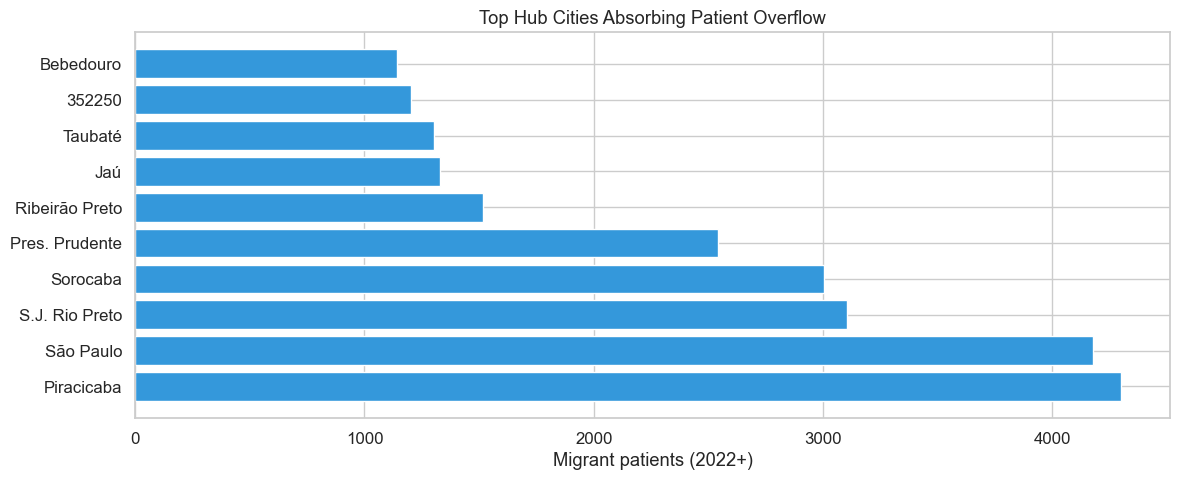

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
hub_vol = hub_cities.head(10).copy()
hub_vol["label"] = [city_name(c) for c in hub_vol.index]
ax.barh(hub_vol["label"], hub_vol["n_migrants"], color="#3498db")
ax.set_xlabel("Migrant patients (2022+)")
ax.set_title("Top Hub Cities Absorbing Patient Overflow")
plt.tight_layout()
plt.savefig(PLOT_DIR / "07_hub_cities.png", dpi=150, bbox_inches="tight")
plt.show()

## City deep dives: Taubaté, Marília, Guarulhos, Limeira

In [6]:
for city_code, name, issue in [
    ("355410", "Taubaté", "No surgical capability, patients migrate"),
    ("352940", "Marília", "High diagnostic admissions, low definitive treatment"),
    ("351880", "Guarulhos", "High ER rate, low definitive treatment"),
    ("352690", "Limeira", "No ureteroscopy despite volume"),
]:
    data = recent[recent["MUNIC_MOV"] == city_code]
    residents = recent[recent["MUNIC_RES"] == city_code]
    if len(data) < 5:
        data = recent[recent["MUNIC_RES"] == city_code]
    print(f"\n{'='*60}")
    print(f"  {name}: {issue}")
    print(f"{'='*60}")
    print(f"  Treated in city: {len(data)}")
    print(f"  Residents needing care: {len(residents)}")
    if len(residents) > 0:
        stayed = residents[residents["MUNIC_MOV"] == city_code]
        print(f"  Residents treated locally: {len(stayed)} ({len(stayed)/len(residents)*100:.0f}%)")
        print(f"  Residents that migrated: {len(residents)-len(stayed)} ({(1-len(stayed)/len(residents))*100:.0f}%)")

    if len(data) > 0:
        print(f"  Avg LOS: {data['DIAS_PERM'].mean():.1f}d")
        print(f"  ER rate: {data['is_emergency'].mean()*100:.0f}%")
        print(f"  Diagnostic %: {(data['proc_category']=='DIAGNOSTIC').mean()*100:.0f}%")
        print(f"  Surgical %: {(data['proc_category']=='SURGICAL').mean()*100:.0f}%")
        print(f"  Ureteroscopy %: {data['has_new_proc'].mean()*100:.0f}%")

        print(f"\n  Top hospitals:")
        for cnes, n in data["CNES"].value_counts().head(3).items():
            h = data[data["CNES"] == cnes]
            print(f"    CNES {cnes}: {n} patients, LOS {h['DIAS_PERM'].mean():.1f}d, "
                  f"surg {(h['proc_category']=='SURGICAL').mean()*100:.0f}%")


  Taubaté: No surgical capability, patients migrate
  Treated in city: 2208
  Residents needing care: 952
  Residents treated locally: 905 (95%)
  Residents that migrated: 47 (5%)
  Avg LOS: 2.2d
  ER rate: 78%
  Diagnostic %: 0%
  Surgical %: 18%
  Ureteroscopy %: 0%

  Top hospitals:
    CNES 3126838: 2201 patients, LOS 2.2d, surg 18%
    CNES 2749319: 7 patients, LOS 3.3d, surg 29%

  Marília: High diagnostic admissions, low definitive treatment
  Treated in city: 885
  Residents needing care: 866
  Residents treated locally: 717 (83%)
  Residents that migrated: 149 (17%)
  Avg LOS: 3.1d
  ER rate: 87%
  Diagnostic %: 61%
  Surgical %: 15%
  Ureteroscopy %: 0%

  Top hospitals:
    CNES 2082349: 885 patients, LOS 3.1d, surg 15%



  Guarulhos: High ER rate, low definitive treatment
  Treated in city: 564
  Residents needing care: 1295
  Residents treated locally: 505 (39%)
  Residents that migrated: 790 (61%)
  Avg LOS: 4.7d
  ER rate: 89%
  Diagnostic %: 83%
  Surgical %: 13%
  Ureteroscopy %: 7%

  Top hospitals:
    CNES 2082861: 242 patients, LOS 4.8d, surg 0%
    CNES 5200105: 138 patients, LOS 3.3d, surg 17%
    CNES 2080338: 133 patients, LOS 5.8d, surg 39%



  Limeira: No ureteroscopy despite volume
  Treated in city: 779
  Residents needing care: 1459
  Residents treated locally: 691 (47%)
  Residents that migrated: 768 (53%)
  Avg LOS: 2.2d
  ER rate: 55%
  Diagnostic %: 12%
  Surgical %: 50%
  Ureteroscopy %: 13%

  Top hospitals:
    CNES 2081458: 776 patients, LOS 2.2d, surg 50%
    CNES 2087103: 3 patients, LOS 1.0d, surg 67%


## Save metrics

In [7]:
metrics = {
    "cities_no_surgery": len(cities_no_surgery),
    "patients_no_surgery": int(cities_no_surgery["n"].sum()),
    "piracicaba_growth_pct": round(growth, 0),
    "piracicaba_migrant_pct": round(piracicaba_new["migrated"].mean() * 100, 0),
}
with open(METRICS_DIR / "geographic_access.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved geographic_access.json")

Saved geographic_access.json
